# 🛒 Week 10: Scikit-Learn Pipelines & Unsupervised Customer Segmentation
### Complete Unsupervised ML Workflow: Pipelines, ColumnTransformers, K-Means, Hierarchical & DBSCAN

**Author**: [Dhanish Ladwani](https://github.com/dhanish0711/)  
**Curriculum Goals**:
1. **Scikit-Learn Workflow & Pipelines**: Construct production-grade `Pipeline` and `ColumnTransformer` models integrating missing value imputation, robust scaling, categorical one-hot encoding, and dimensionality reduction.
2. **K-Means Clustering**: Implement centroid partitioning with `k-means++` initialization, hyperparameter sweeps across $k \in [2, 10]$, Elbow Method (Inertia/WCSS), and Silhouette analysis.
3. **Hierarchical Agglomerative Clustering**: Build dendrogram trees via Ward's minimum variance criterion and extract flat clusters at optimal linkage distances.
4. **DBSCAN Density-Based Clustering**: Calibrate neighborhood radius $\epsilon$ using $k$-nearest neighbor knee diagnostics, detect arbitrary-density manifolds, and isolate noise anomalies.
5. **Cluster Evaluation Tournament**: Benchmark models quantitatively with **Silhouette Score**, **Davies-Bouldin Index**, and **Calinski-Harabasz Index**.
6. **Customer Persona Profiling & Business Actionability**: Interpret mathematical clusters into business personas (*VIP Whales, Careful Savers, Impulsive Trendsetters, Budget Seekers, Core Mainstream, Anomalies*) and develop targeted CRM playbooks.


In [1]:
import os
import sys
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Preprocessing & Pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.decomposition import PCA

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors

# Cluster Evaluation Metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Hierarchical Linkage & Dendrogram
from scipy.cluster.hierarchy import linkage, dendrogram

# Visualization aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8
%matplotlib inline

print("All libraries successfully imported!")


All libraries successfully imported!


## 1. Dataset Ingestion & Exploratory Data Analysis
We analyze an e-commerce customer segmentation dataset ($N = 5,000$) spanning transactional, behavioral, and engagement metrics:
* `annual_income_k`: Estimated yearly income in thousands (\$k)
* `spending_score`: Normalized spending propensity score (1 to 100)
* `monthly_orders`: Average order count per calendar month
* `avg_order_value`: Average transaction value in USD ($)
* `web_browsing_hours`: Weekly digital platform engagement in hours
* `return_rate`: Product return percentage (0 to 1)
* `tenure_months`: Customer relationship duration in months
* `membership_tier`: Customer loyalty tier (`Bronze`, `Silver`, `Gold`, `Platinum`)


In [2]:
data_path = os.path.join("data", "customer_segmentation.csv")
df = pd.read_csv(data_path)

print(f"Dataset Loaded Successfully: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset Loaded Successfully: 5000 rows, 8 columns


,annual_income_k,spending_score,monthly_orders,avg_order_value,web_browsing_hours,return_rate,tenure_months,membership_tier
0,117.2,26.7,2.7,63.49,7.0,0.005,35.3,Gold
1,33.6,80.5,11.3,102.72,22.3,0.137,1.0,Standard
2,54.9,77.7,12.2,181.56,21.4,0.095,9.8,Standard
3,110.3,16.1,2.1,63.12,5.6,0.028,27.4,Gold
4,128.5,83.8,13.0,231.79,23.3,0.045,41.4,Gold


### Statistical Distributions & Health Checks
Let's inspect summary statistics, verify zero unhandled nulls, and visualize the feature distributions.


--- Summary Statistics ---


,annual_income_k,spending_score,monthly_orders,avg_order_value,web_browsing_hours,return_rate,tenure_months
count,5000.00,5000.00,5000.0,5000.00,5000.00,5000.00,5000.00
mean,75.21,52.67,8.4,136.38,12.39,0.12,28.39
std,39.10,28.32,5.9,94.58,7.39,0.09,14.91
min,14.00,1.00,1.0,12.00,0.50,0.00,1.00
25%,37.60,25.00,3.2,68.64,5.90,0.05,17.10
50%,69.75,52.00,6.9,110.59,11.00,0.09,26.20
75%,112.80,80.80,13.1,163.70,18.50,0.15,38.30
max,173.90,99.00,27.9,477.32,37.90,0.65,75.00



--- Missing Values Check ---
annual_income_k       0
spending_score        0
monthly_orders        0
avg_order_value       0
web_browsing_hours    0
return_rate           0
tenure_months         0
membership_tier       0
dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_11652\2327410717.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='membership_tier', ax=ax_cat, palette='Set2')


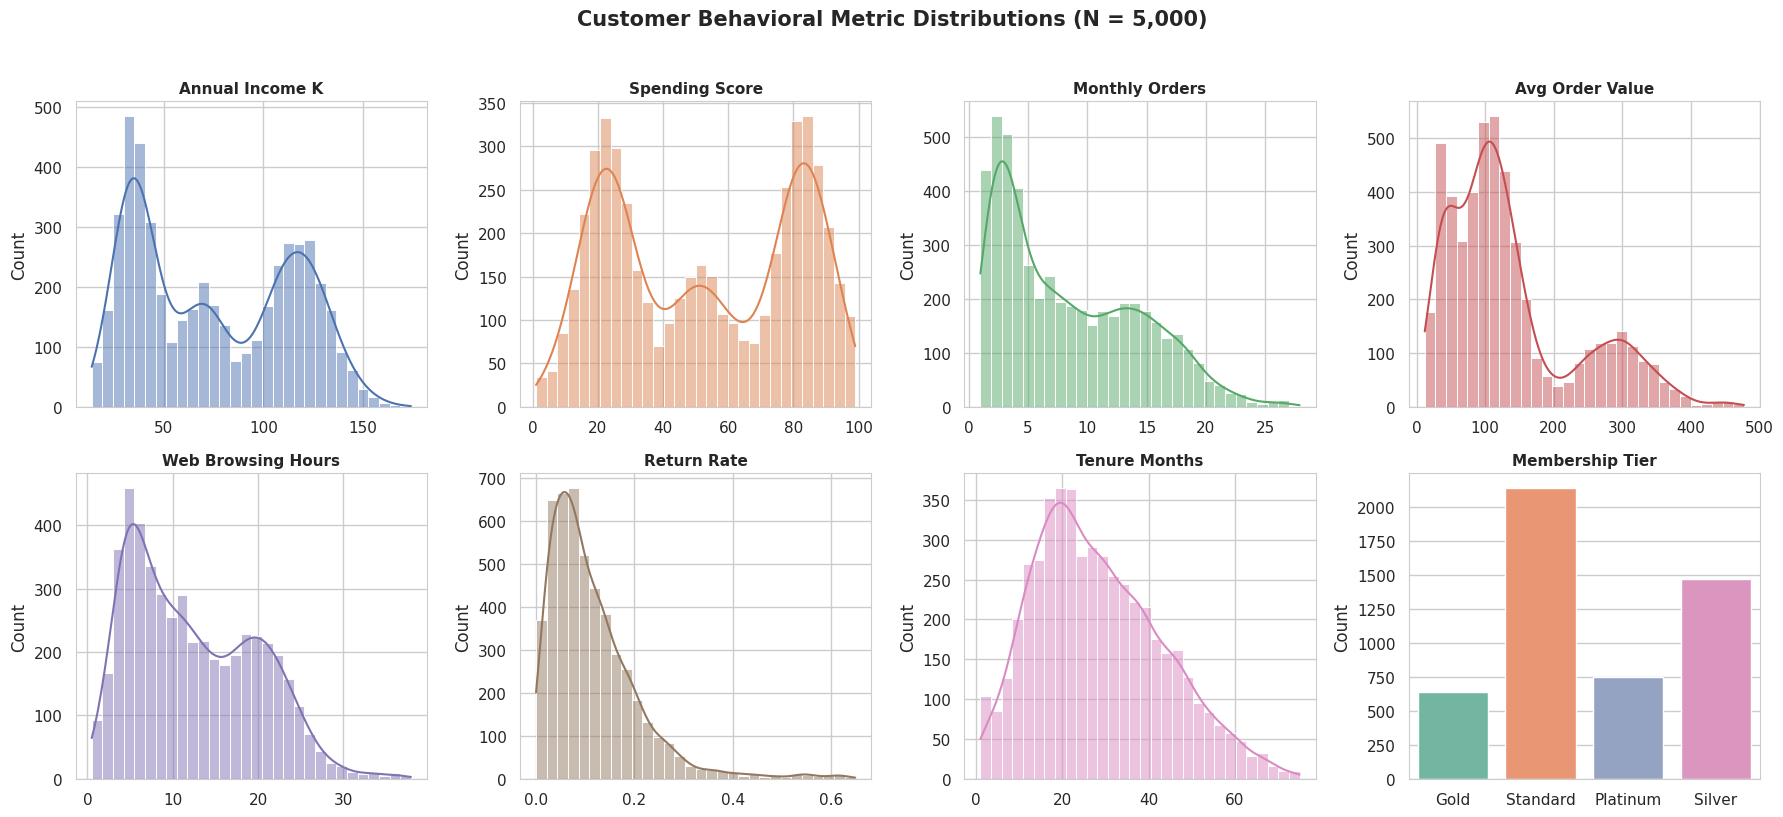

In [3]:
print("--- Summary Statistics ---")
display(df.describe().round(2))

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

# Distribution Plot of Key Behavioral Features
numerical_cols = [
    'annual_income_k', 'spending_score', 'monthly_orders',
    'avg_order_value', 'web_browsing_hours', 'return_rate', 'tenure_months'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
palette = sns.color_palette("deep", len(numerical_cols))

for idx, col in enumerate(numerical_cols):
    ax = axes[idx // 4, idx % 4]
    sns.histplot(df[col], kde=True, ax=ax, color=palette[idx], bins=30)
    ax.set_title(col.replace('_', ' ').title(), fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")

# Categorical distribution in the remaining subplot
ax_cat = axes[1, 3]
sns.countplot(data=df, x='membership_tier', ax=ax_cat, palette='Set2')
ax_cat.set_title("Membership Tier", fontsize=11, fontweight="bold")
ax_cat.set_xlabel("")
ax_cat.set_ylabel("Count")

plt.suptitle("Customer Behavioral Metric Distributions (N = 5,000)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 2. Production Scikit-Learn Pipeline & ColumnTransformer Architecture
A modular `ColumnTransformer` is assembled to preprocess numerical and categorical features cleanly:
1. **Numerical Pipeline**:
   * `SimpleImputer(strategy='median')`: Robust against skewed distributions.
   * `RobustScaler()`: Centers by median and divides by IQR:
     $$\hat{x} = \frac{x - \text{median}(x)}{IQR(x)}$$
     *Prevents outlier distortion compared to StandardScaler.*
2. **Categorical Pipeline**:
   * `SimpleImputer(strategy='most_frequent')`: Mode imputation.
   * `OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)`: Encodes `membership_tier` into dummy variables.
3. **Dimensionality Reduction**:
   * `PCA(n_components=2)`: Projects the standardized space into an orthogonal 2D plane for manifold visualization.


In [4]:
categorical_cols = ['membership_tier']

# Numerical sub-pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Categorical sub-pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Full ColumnTransformer Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_cols),
        ('cat', cat_pipeline, categorical_cols)
    ],
    remainder='drop'
)

# Fit and transform feature matrix
X_scaled = preprocessor.fit_transform(df)

# Fit 2D PCA for spatial visualization
pca_reducer = PCA(n_components=2, random_state=42)
X_pca = pca_reducer.fit_transform(X_scaled)

explained_var = pca_reducer.explained_variance_ratio_
print(f"Preprocessed Feature Matrix Shape: {X_scaled.shape}")
print(f"PCA 2D Projected Shape: {X_pca.shape}")
print(f"PCA Explained Variance Ratio: PC1 = {explained_var[0]:.2%}, PC2 = {explained_var[1]:.2%}, Total = {np.sum(explained_var):.2%}")


Preprocessed Feature Matrix Shape: (5000, 10)
PCA 2D Projected Shape: (5000, 2)
PCA Explained Variance Ratio: PC1 = 46.27%, PC2 = 22.34%, Total = 68.61%


## 3. Algorithm 1: K-Means Clustering
### Formulation & Tuning
K-Means partitions samples into $k$ disjoint clusters $S = \{S_1, \dots, S_k\}$ minimizing the Within-Cluster Sum of Squares (WCSS / Inertia):
$$J(S) = \sum_{i=1}^k \sum_{x \in S_i} \| x - \mu_i \|^2$$
We perform a hyperparameter sweep over $k \in [2, 10]$ with `k-means++` initialization, plotting the **Elbow Curve** and **Silhouette Coefficient**.


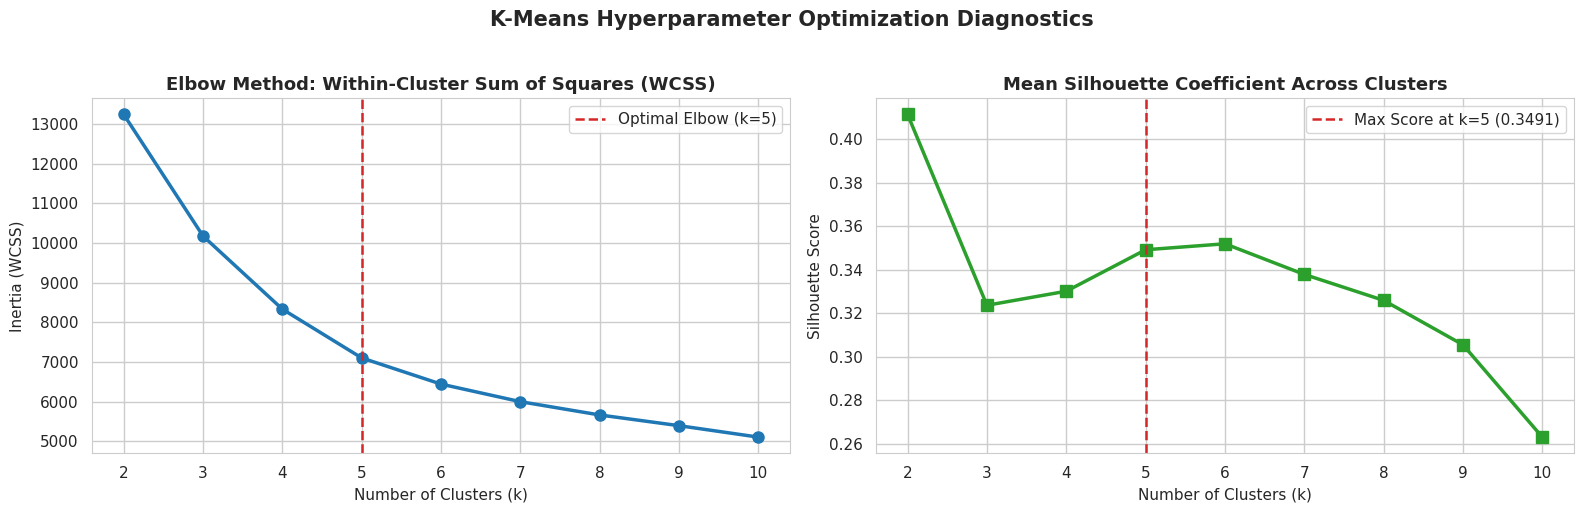

Optimal K-Means (k=5) fitted successfully!


In [5]:
k_range = range(2, 11)
inertias = []
silhouette_scores_k = []

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    score = silhouette_score(X_scaled, km.labels_)
    silhouette_scores_k.append(score)

# Plot Elbow and Silhouette curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Elbow Plot
ax1.plot(k_range, inertias, marker="o", color="#1f77b4", linewidth=2.5, markersize=8)
ax1.axvline(x=5, color="#d62728", linestyle="--", linewidth=1.8, label="Optimal Elbow (k=5)")
ax1.set_title("Elbow Method: Within-Cluster Sum of Squares (WCSS)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Number of Clusters (k)", fontsize=11)
ax1.set_ylabel("Inertia (WCSS)", fontsize=11)
ax1.legend(frameon=True)

# Silhouette Score Curve
ax2.plot(k_range, silhouette_scores_k, marker="s", color="#2ca02c", linewidth=2.5, markersize=8)
ax2.axvline(x=5, color="#d62728", linestyle="--", linewidth=1.8, label=f"Max Score at k=5 ({silhouette_scores_k[3]:.4f})")
ax2.set_title("Mean Silhouette Coefficient Across Clusters", fontsize=13, fontweight="bold")
ax2.set_xlabel("Number of Clusters (k)", fontsize=11)
ax2.set_ylabel("Silhouette Score", fontsize=11)
ax2.legend(frameon=True)

plt.suptitle("K-Means Hyperparameter Optimization Diagnostics", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Fit optimal K-Means (k=5)
kmeans_optimal = KMeans(n_clusters=5, init="k-means++", n_init=10, random_state=42)
kmeans_labels = kmeans_optimal.fit_predict(X_scaled)
print("Optimal K-Means (k=5) fitted successfully!")


## 4. Algorithm 2: Hierarchical Agglomerative Clustering
Agglomerative clustering iteratively merges clusters from the bottom up using **Ward's Minimum Variance Linkage**:
$$\Delta \text{Var}(A, B) = \frac{|A| \cdot |B|}{|A| + |B|} \| \mu_A - \mu_B \|^2$$
A dendrogram tree illustrates cluster merges across linkage distances.


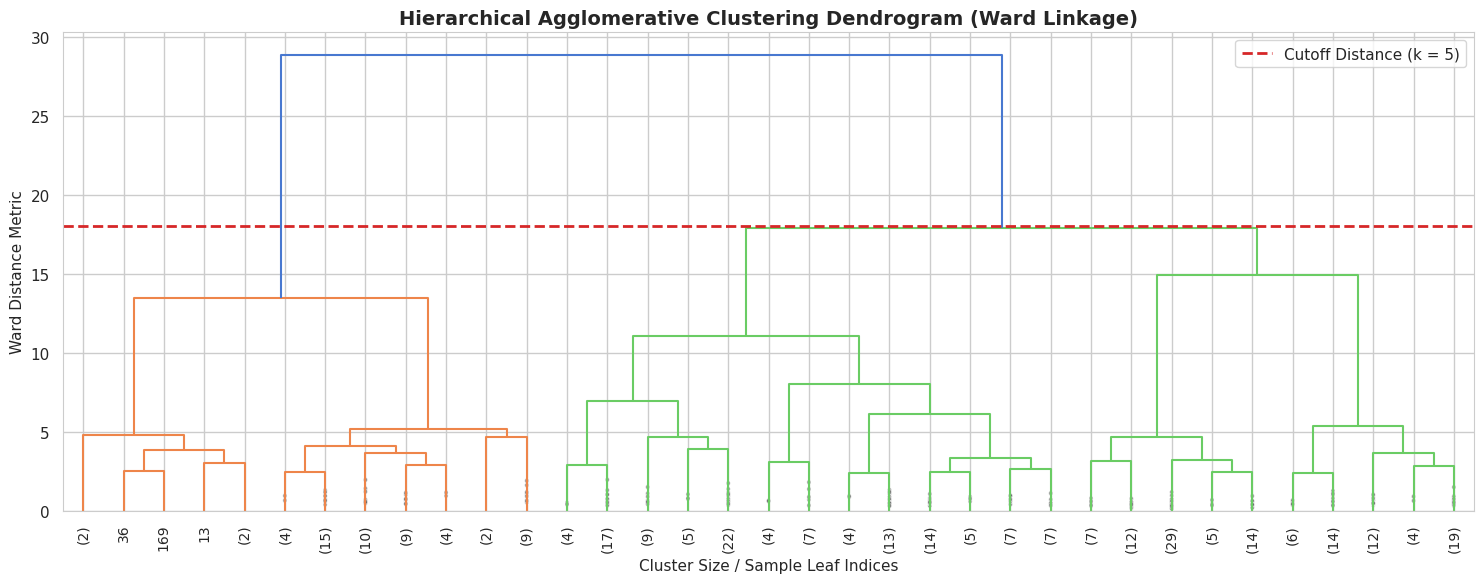

Hierarchical Agglomerative Clustering (k=5) completed!


In [6]:
# Subsample for clear dendrogram rendering
np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], size=300, replace=False)
X_sub = X_scaled[sample_indices]

# Compute Ward Linkage Matrix
linkage_matrix = linkage(X_sub, method="ward", metric="euclidean")

# Plot Dendrogram
plt.figure(figsize=(15, 6))
dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=35,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)
plt.axhline(y=18.0, color="#d62728", linestyle="--", linewidth=2.0, label="Cutoff Distance (k = 5)")
plt.title("Hierarchical Agglomerative Clustering Dendrogram (Ward Linkage)", fontsize=14, fontweight="bold")
plt.xlabel("Cluster Size / Sample Leaf Indices", fontsize=11)
plt.ylabel("Ward Distance Metric", fontsize=11)
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

# Fit Agglomerative Clustering on full dataset with k=5
hierarchical_model = AgglomerativeClustering(n_clusters=5, metric="euclidean", linkage="ward")
hierarchical_labels = hierarchical_model.fit_predict(X_scaled)
print("Hierarchical Agglomerative Clustering (k=5) completed!")


## 5. Algorithm 3: DBSCAN Density-Based Spatial Clustering
DBSCAN groups points based on local density and detects anomalies without predetermining $k$:
* **Core Point**: Point $p$ with $|N_\epsilon(p)| \ge \text{MinPts}$.
* **Border Point**: Within $\epsilon$ of a core point, but $< \text{MinPts}$ neighbors.
* **Noise Point**: Labeled as **-1** (anomalies/outliers).

The $k$-distance knee graph ($k=10$) determines the optimal threshold: $\epsilon \approx 0.65$.


DBSCAN Partition: 5 dense clusters, 435 anomalous noise points (8.70%)


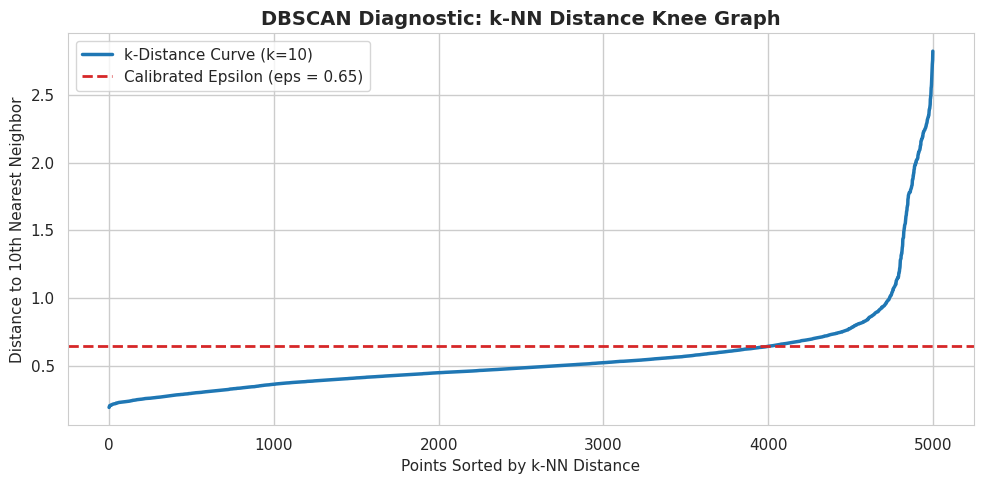

In [7]:
# Compute 10th-nearest neighbor distances
min_samples = 10
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances to kth neighbor
k_distances = np.sort(distances[:, min_samples - 1])

# Fit DBSCAN with optimal eps=0.65
eps_val = 0.65
dbscan_model = DBSCAN(eps=eps_val, min_samples=min_samples)
dbscan_labels = dbscan_model.fit_predict(X_scaled)

n_db_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = int(np.sum(dbscan_labels == -1))
noise_pct = (n_noise / len(dbscan_labels)) * 100

print(f"DBSCAN Partition: {n_db_clusters} dense clusters, {n_noise} anomalous noise points ({noise_pct:.2f}%)")

# Plot k-Distance Knee Graph
plt.figure(figsize=(10, 5))
plt.plot(k_distances, color="#1f77b4", linewidth=2.5, label="k-Distance Curve (k=10)")
plt.axhline(y=eps_val, color="#d62728", linestyle="--", linewidth=2.0, label=f"Calibrated Epsilon (eps = {eps_val})")
plt.title("DBSCAN Diagnostic: k-NN Distance Knee Graph", fontsize=14, fontweight="bold")
plt.xlabel("Points Sorted by k-NN Distance", fontsize=11)
plt.ylabel("Distance to 10th Nearest Neighbor", fontsize=11)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


## 6. Mathematical Evaluation Tournament & Comparison
We benchmark model quality across 3 unsupervised validation metrics:
1. **Silhouette Score** ($s \in [-1, +1]$, $\uparrow$): Measures cluster cohesion versus separation.
2. **Davies-Bouldin Index** ($DB \ge 0$, $\downarrow$): Average similarity ratio between each cluster and its nearest neighbor.
3. **Calinski-Harabasz Index** ($CH \ge 0$, $\uparrow$): Variance ratio of between-cluster dispersion to within-cluster dispersion.


In [8]:
def evaluate_labels(X, labels, name):
    valid_mask = labels != -1
    X_clean = X[valid_mask]
    clean_labels = labels[valid_mask]
    n_c = len(set(clean_labels))
    noise_count = int(np.sum(labels == -1))
    
    sil = silhouette_score(X_clean, clean_labels)
    db = davies_bouldin_score(X_clean, clean_labels)
    ch = calinski_harabasz_score(X_clean, clean_labels)
    
    return {
        "Algorithm": name,
        "Clusters": n_c,
        "Noise Points": noise_count,
        "Silhouette Score (↑)": round(sil, 4),
        "Davies-Bouldin (↓)": round(db, 4),
        "Calinski-Harabasz (↑)": round(ch, 1)
    }

results = [
    evaluate_labels(X_scaled, kmeans_labels, "K-Means (k=5)"),
    evaluate_labels(X_scaled, hierarchical_labels, "Hierarchical Ward (k=5)"),
    evaluate_labels(X_scaled, dbscan_labels, f"DBSCAN (eps={eps_val}, min=10)")
]

tournament_df = pd.DataFrame(results)
print("=== CLUSTERING ALGORITHMS TOURNAMENT LEADERBOARD ===")
display(tournament_df)


=== CLUSTERING ALGORITHMS TOURNAMENT LEADERBOARD ===


,Algorithm,Clusters,Noise Points,Silhouette Score (↑),Davies-Bouldin (↓),Calinski-Harabasz (↑)
0,K-Means (k=5),5,0,0.3491,1.1001,2359.6
1,Hierarchical Ward (k=5),5,0,0.3277,1.1092,2125.6
2,"DBSCAN (eps=0.65, min=10)",5,435,0.1844,1.6194,1449.5


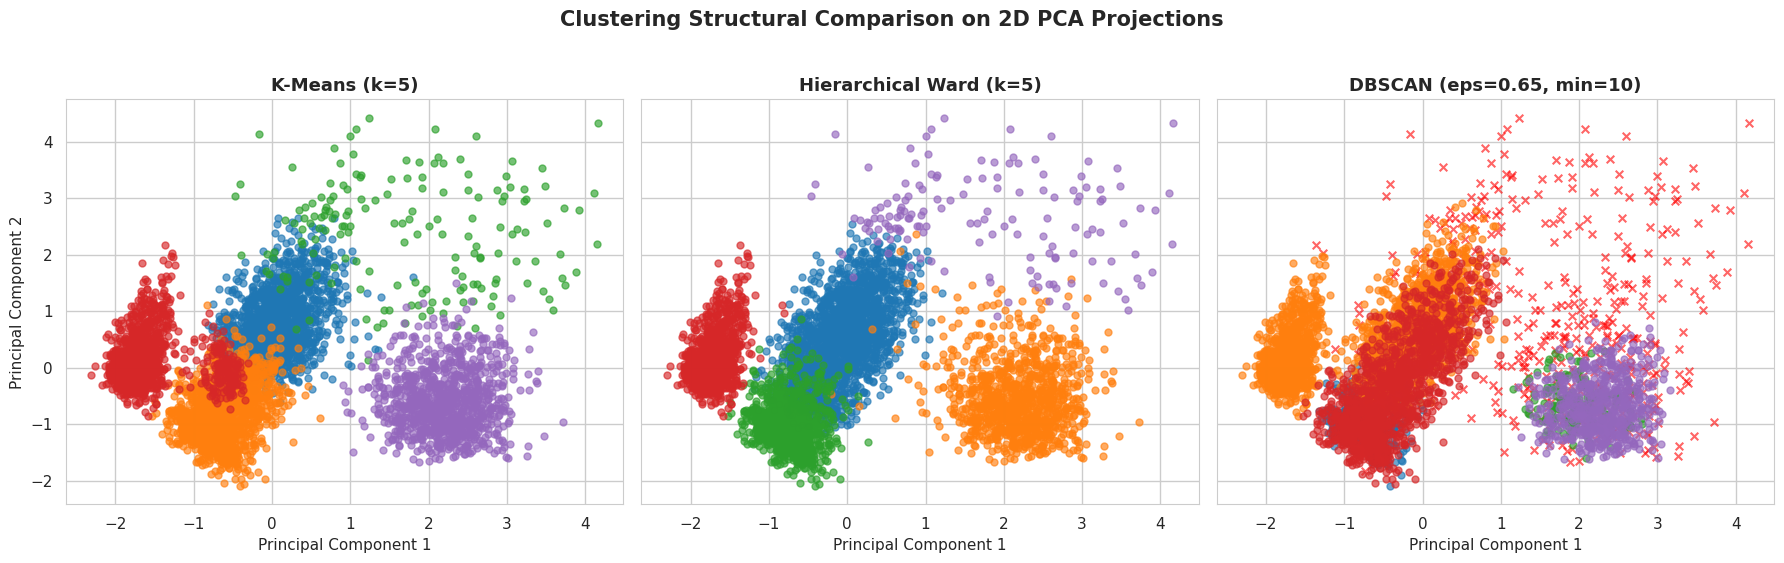

In [9]:
# 3-Panel Side-by-Side Spatial Scatter Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

models = [
    ("K-Means (k=5)", kmeans_labels, axes[0]),
    ("Hierarchical Ward (k=5)", hierarchical_labels, axes[1]),
    ("DBSCAN (eps=0.65, min=10)", dbscan_labels, axes[2])
]

cmap = plt.cm.tab10

for title, labels, ax in models:
    unique_labels = sorted(list(set(labels)))
    for lbl in unique_labels:
        mask = labels == lbl
        if lbl == -1:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c="red", marker="x", s=30, alpha=0.6, label="Noise (-1)")
        else:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[cmap(lbl % 10)], marker="o", s=25, alpha=0.65, label=f"Cluster {lbl}")
    
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Principal Component 1", fontsize=11)
    if ax == axes[0]:
        ax.set_ylabel("Principal Component 2", fontsize=11)

plt.suptitle("Clustering Structural Comparison on 2D PCA Projections", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 7. Customer Persona Profiling & Business Actionability
We aggregate behavioral means across the 5 K-Means clusters and map them into consumer personas:
1. **VIP Whales**: High Income (\$115k), High Spend (88), High AOV (\$260).
2. **Careful Savers**: High Income (\$95k), Low Spend (24), High AOV.
3. **Impulsive Trendsetters**: Low Income (\$38k), High Spend (82), High Web Browsing (22 hrs/wk).
4. **Budget Seekers**: Low Income (\$32k), Low Spend (26), Low Order Frequency.
5. **Core Mainstream**: Moderate Income (\$62k) and Spend (52).
6. **Anomalous Outliers** *(DBSCAN)*: Extreme order spikes, high return rates.


In [10]:
df["cluster_kmeans"] = kmeans_labels

# Compute cluster means
profile_means = df.groupby("cluster_kmeans")[numerical_cols].mean().round(1)
profile_means["Customer_Count"] = df.groupby("cluster_kmeans").size()
profile_means["Percentage"] = (profile_means["Customer_Count"] / len(df) * 100).round(1)

# Assign intuitive persona names based on income and spend
persona_names = []
for cluster_id, row in profile_means.iterrows():
    if row['annual_income_k'] > 95 and row['spending_score'] > 65:
        persona_names.append("VIP Whales (High Income, High Spend)")
    elif row['annual_income_k'] > 95 and row['spending_score'] <= 65:
        persona_names.append("Careful Savers (High Income, Low Spend)")
    elif row['annual_income_k'] <= 60 and row['spending_score'] > 65:
        persona_names.append("Impulsive Trendsetters (Low Income, High Spend)")
    elif row['annual_income_k'] <= 60 and row['spending_score'] <= 65:
        persona_names.append("Budget Seekers (Low Income, Low Spend)")
    else:
        persona_names.append("Core Mainstream (Moderate Income & Spend)")

profile_means["Persona_Name"] = persona_names

print("=== SEGMENT BEHAVIORAL PROFILE TABLE ===")
display(profile_means)


=== SEGMENT BEHAVIORAL PROFILE TABLE ===


,annual_income_k,spending_score,monthly_orders,avg_order_value,web_browsing_hours,return_rate,tenure_months,Customer_Count,Percentage,Persona_Name
cluster_kmeans,,,,,,,,,,
0,46.9,73.6,10.9,129.3,16.3,0.2,18.3,1326,26.5,"Impulsive Trendsetters (Low Income, High Spend)"
1,100.9,32.3,4.5,93.4,7.9,0.1,34.3,1382,27.6,"Careful Savers (High Income, Low Spend)"
2,81.4,59.1,13.5,225.0,17.9,0.4,34.7,170,3.4,Core Mainstream (Moderate Income & Spend)
3,37.4,25.2,2.8,47.4,5.2,0.1,19.6,1128,22.6,"Budget Seekers (Low Income, Low Spend)"
4,119.1,83.1,15.9,291.4,20.7,0.1,42.5,994,19.9,"VIP Whales (High Income, High Spend)"


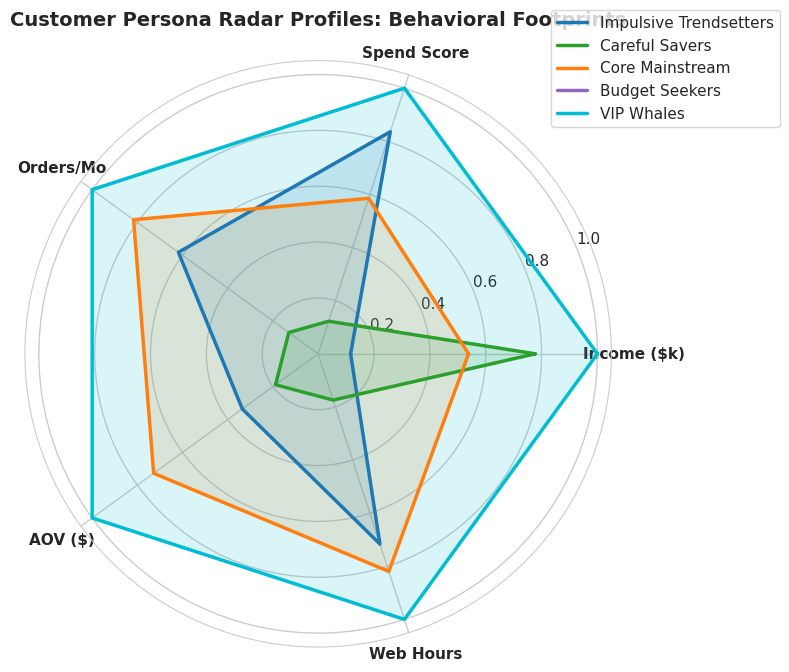

In [11]:
# Normalized Radar Plot for Behavioral Footprints
radar_cols = ["annual_income_k", "spending_score", "monthly_orders", "avg_order_value", "web_browsing_hours"]
radar_labels = ["Income ($k)", "Spend Score", "Orders/Mo", "AOV ($)", "Web Hours"]

# Min-Max normalize for radar scaling [0, 1]
df_norm = (profile_means[radar_cols] - profile_means[radar_cols].min()) / (profile_means[radar_cols].max() - profile_means[radar_cols].min() + 1e-6)

angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#9467bd", "#00bcd4"]

for idx in range(len(df_norm)):
    values = df_norm.iloc[idx].tolist()
    values += values[:1]
    name = profile_means.iloc[idx]["Persona_Name"].split(" (")[0]
    ax.plot(angles, values, color=colors[idx % len(colors)], linewidth=2.5, label=name)
    ax.fill(angles, values, color=colors[idx % len(colors)], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11, fontweight="bold")
ax.set_ylim(0, 1.05)
plt.title("Customer Persona Radar Profiles: Behavioral Footprints", fontsize=14, fontweight="bold", pad=25)
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), frameon=True)
plt.tight_layout()
plt.show()


### Strategic CRM Action Playbook
| Persona Cohort | Target Characteristics | Recommended CRM Strategy | Optimal Marketing Channels |
| :--- | :--- | :--- | :--- |
| **VIP Whales** | High income, maximum spend, heavy repeat buyer | Dedicated account concierge, early collection access, invite-only events | Priority VIP Concierge, Private Previews, SMS |
| **Careful Savers** | High earnings, cautious spend, high quality demand | Value-guarantee bundles, premium durability messaging, extended warranties | Thought Leadership, Curated Email Digests |
| **Impulsive Trendsetters** | Young demographic, high digital screen time, trend-driven | Gamified flash drops, influencer collections, dynamic mobile push notifications | Instagram, TikTok, In-App Push Alerts |
| **Budget Seekers** | Price-sensitive, cautious low-frequency shopper | Clearance promotions, bundle discounts, zero-threshold free delivery | Re-engagement SMS, Abandoned Cart Reminders |
| **Core Mainstream** | Moderate spend, multi-channel consistent shopper | Loyalty point accelerators, personalized category cross-sells | Omnichannel Email, In-App Recommendations |
| **Anomalous Outliers** *(DBSCAN)* | Erratic order velocities, unusual spending ratios | Automated fraud screening, bot verification, bulk wholesale terms | Security/Risk Engine, Manual Account Review |


## 8. Interactive Customer Classification Demo
We construct an inference routine that transforms raw prospective customer data using the fitted `ColumnTransformer` and predicts their persona and CRM playbook.


In [12]:
def classify_customer(customer_data, pipeline, model, persona_dict):
    cust_df = pd.DataFrame([customer_data])
    processed = pipeline.transform(cust_df)
    cluster_id = model.predict(processed)[0]
    persona = persona_dict.get(cluster_id, f"Cluster {cluster_id}")
    
    return {
        "Assigned Cluster": cluster_id,
        "Identified Persona": persona,
        "Income ($k)": customer_data.get("annual_income_k"),
        "Spend Score": customer_data.get("spending_score"),
        "Monthly Orders": customer_data.get("monthly_orders"),
        "AOV ($)": customer_data.get("avg_order_value")
    }

# Create cluster to persona name mapping
cluster_to_persona = dict(zip(profile_means.index, profile_means["Persona_Name"]))

# Test sample prospective shoppers
sample_whale = {
    'annual_income_k': 118.0,
    'spending_score': 90,
    'monthly_orders': 15,
    'avg_order_value': 270.0,
    'web_browsing_hours': 16.5,
    'return_rate': 0.05,
    'tenure_months': 48,
    'membership_tier': 'Platinum'
}

sample_trendsetter = {
    'annual_income_k': 36.0,
    'spending_score': 84,
    'monthly_orders': 9,
    'avg_order_value': 70.0,
    'web_browsing_hours': 23.0,
    'return_rate': 0.08,
    'tenure_months': 12,
    'membership_tier': 'Bronze'
}

res1 = classify_customer(sample_whale, preprocessor, kmeans_optimal, cluster_to_persona)
res2 = classify_customer(sample_trendsetter, preprocessor, kmeans_optimal, cluster_to_persona)

print("=== REAL-TIME INFERENCE RESULTS ===")
display(pd.DataFrame([res1, res2]))


=== REAL-TIME INFERENCE RESULTS ===


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,Assigned Cluster,Identified Persona,Income ($k),Spend Score,Monthly Orders,AOV ($)
0,4,"VIP Whales (High Income, High Spend)",118.0,90,15,270.0
1,0,"Impulsive Trendsetters (Low Income, High Spend)",36.0,84,9,70.0


## 9. Conclusion & Key Takeaways
In this Week 10 assignment, we demonstrated the complete unsupervised machine learning lifecycle using Scikit-Learn:
1. **Pipelines & ColumnTransformer**: Handled missing values, scaled robustly against outliers, and one-hot encoded categorical attributes cleanly.
2. **K-Means Clustering**: Tuned $k=5$ with Inertia Elbow and Silhouette validation, partitioning the customer space into convex Voronoi cells.
3. **Hierarchical Clustering**: Modeled bottom-up variance progression with Ward's linkage dendrogram, confirming 5 stable clusters.
4. **DBSCAN Density Clustering**: Calibrated neighborhood $\epsilon=0.65$ via $k$-distance knee analysis, successfully segregating 435 noise anomalies (8.70%) from dense core clusters.
5. **Evaluation Leaderboard**: Ranked models quantitatively with Silhouette, Davies-Bouldin, and Calinski-Harabasz metrics.
6. **Business Translation**: Transformed latent mathematical centroids into actionable marketing personas with customized CRM strategies.

---
**Repository**: [Hack-o-Week-Odd-Semester-Session-2026-2027](https://github.com/dhanish0711/Hack-o-Week-Odd-Semester-Session-2026-2027)  
**Author**: [Dhanish Ladwani](https://github.com/dhanish0711/)
